# 1 - Sales Dashboard - Data Visualization

<img src='https://media.licdn.com/dms/image/v2/C4E12AQEkOQReC-oSHw/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1583186806999?e=2147483647&v=beta&t=GlGAmarMUbBopsfnrOlYHiof0g4qxdLtKgjzcFEtSIo'>

Bu çalışmada satış verileri üzerinden görselleştirme odaklı bir dashboard oluşturarak satış performansını farklı açılardan inceleyeceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Temel istatistik ve ilişki analizi
6. KPI analizi
7. Kategori bazlı görselleştirme
8. Bölge bazlı görselleştirme
9. Zaman bazlı görselleştirme
10. Sonuç


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 1. Veriyi Yükleme

In [6]:
# Bu bölümde zip dosyasını Google Drive içinden açıp çalışma alanına çıkaracağım.

In [7]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Superstore Sales Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['.config', 'drive', 'samplesuperstore.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [8]:
# Bu bölümde csv dosyasını okuyup veri setinin genel yapısını inceleyeceğim.

In [9]:
df = pd.read_csv('/content/samplesuperstore.csv', encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [10]:
df.shape


(10194, 21)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [12]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


## 3. Veri Temizleme

In [13]:
# Bu bölümde tarih sütunlarını datetime tipine çevirip veri setini analiz için hazırlayacağım.

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 4. Feature Engineering

In [15]:
# Bu bölümde yıl, ay ve sipariş süresi gibi analizde kullanacağım yeni sütunları oluşturacağım.

In [16]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()
df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Ship Duration
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,January,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,January,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,January,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,January,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,January,7


## 5. Temel İstatistik ve İlişki Analizi

In [17]:
# Bu bölümde describe, korelasyon ve temel grafiklerle veri setindeki ilişkileri inceleyeceğim.

In [18]:
df.describe(include='all')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Ship Duration
count,10194.000000,10194,10194,10194,10194,10194,10194,10194,10194,10194,...,10194,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194,10194.000000
unique,NaN,5111,NaN,NaN,4,804,800,3,2,542,...,3,17,1849,NaN,NaN,NaN,NaN,NaN,12,NaN
top,NaN,US-2026-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,November,NaN
freq,NaN,14,NaN,NaN,6120,41,41,5281,9994,915,...,6128,1548,50,NaN,NaN,NaN,NaN,NaN,1474,NaN
mean,5097.500000,NaN,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,228.225854,3.791838,0.155385,28.673417,2024.720129,NaN,3.961350
min,1.000000,NaN,2023-01-03 00:00:00,2023-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,2023.000000,NaN,0.000000
25%,2549.250000,NaN,2024-05-14 00:00:00,2024-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,17.220000,2.000000,0.000000,1.760800,2024.000000,NaN,3.000000
50%,5097.500000,NaN,2025-06-25 00:00:00,2025-06-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,53.910000,3.000000,0.200000,8.690000,2025.000000,NaN,4.000000
75%,7645.750000,NaN,2026-05-14 00:00:00,2026-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,209.500000,5.000000,0.200000,29.297925,2026.000000,NaN,5.000000
max,10194.000000,NaN,2026-12-30 00:00:00,2027-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000,2026.000000,NaN,11.000000


In [19]:
corr_df = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Duration']].corr(numeric_only=True)
corr_df


,Sales,Quantity,Discount,Profit,Ship Duration
Sales,1.000000,0.198457,-0.027756,0.481460,-0.006921
Quantity,0.198457,1.000000,0.007475,0.066145,0.021068
Discount,-0.027756,0.007475,1.000000,-0.218882,-0.001774
Profit,0.481460,0.066145,-0.218882,1.000000,-0.004350
Ship Duration,-0.006921,0.021068,-0.001774,-0.004350,1.000000


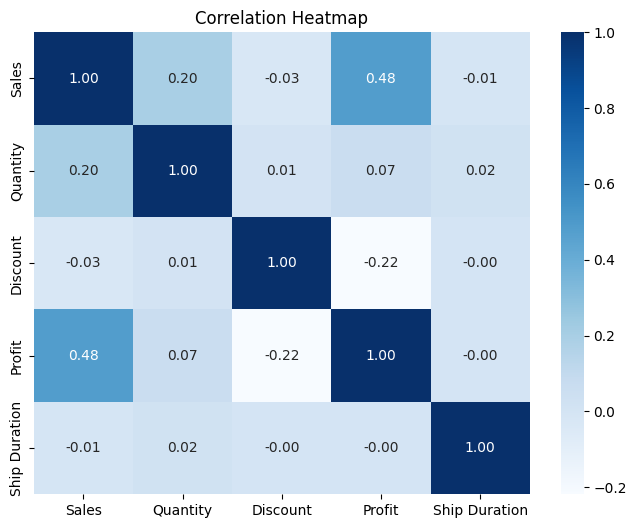

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


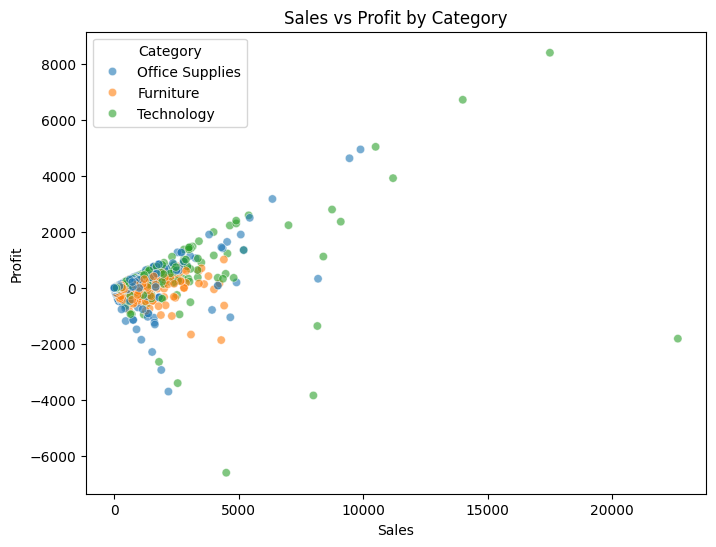

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.6)
plt.title('Sales vs Profit by Category')
plt.show()


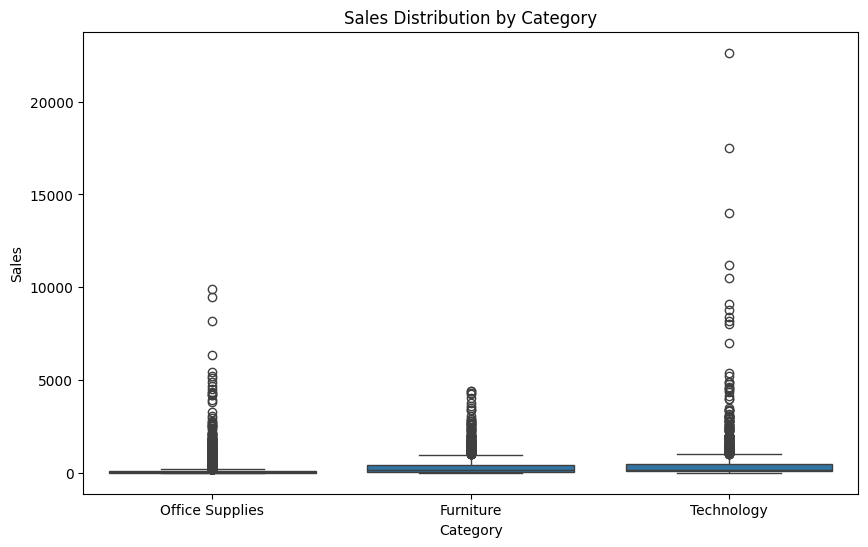

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category', y='Sales')
plt.title('Sales Distribution by Category')
plt.show()


## 6. KPI Analizi

In [23]:
# Bu bölümde toplam satış, toplam kâr ve toplam sipariş sayısı gibi temel KPI değerlerini inceleyeceğim.

In [24]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print('Total Sales:', round(total_sales, 2))
print('Total Profit:', round(total_profit, 2))
print('Total Orders:', total_orders)


Total Sales: 2326534.35
Total Profit: 292296.81
Total Orders: 5111


## 7. Kategori Bazlı Görselleştirme

In [25]:
# Bu bölümde kategori ve alt kategori bazında satış ile kâr dağılımını görselleştireceğim.

In [26]:
category_sales = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
fig = px.bar(category_sales, x='Category', y=['Sales', 'Profit'], barmode='group', title='Sales and Profit by Category')
fig.show()


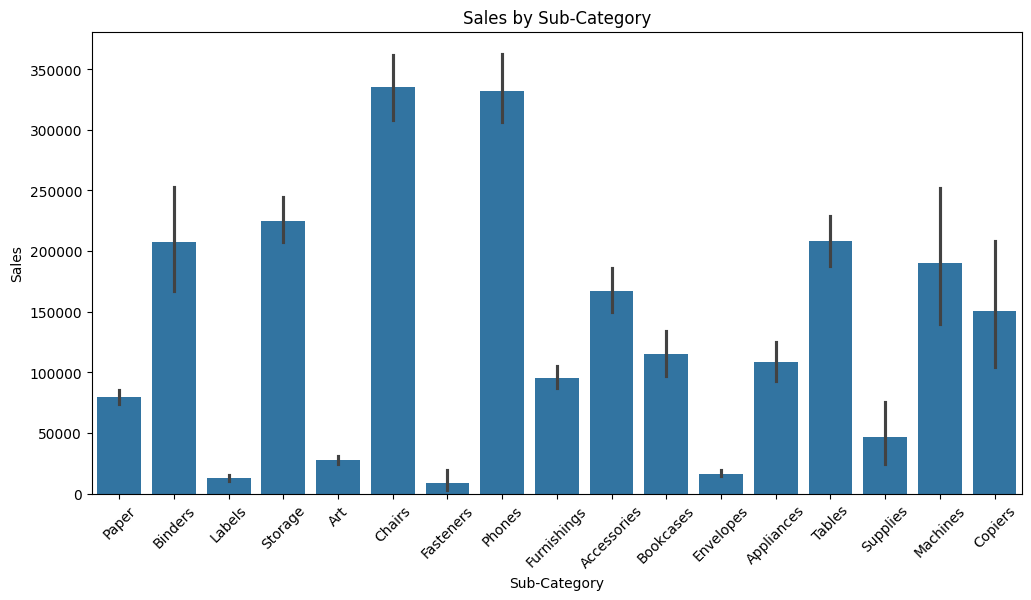

In [27]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Sub-Category', y='Sales', estimator=sum)
plt.xticks(rotation=45)
plt.title('Sales by Sub-Category')
plt.show()


## 8. Bölge Bazlı Görselleştirme

In [28]:
# Bu bölümde bölgelere göre satış performansını inceleyeceğim.

In [29]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
fig = px.pie(region_sales, names='Region', values='Sales', title='Sales by Region')
fig.show()


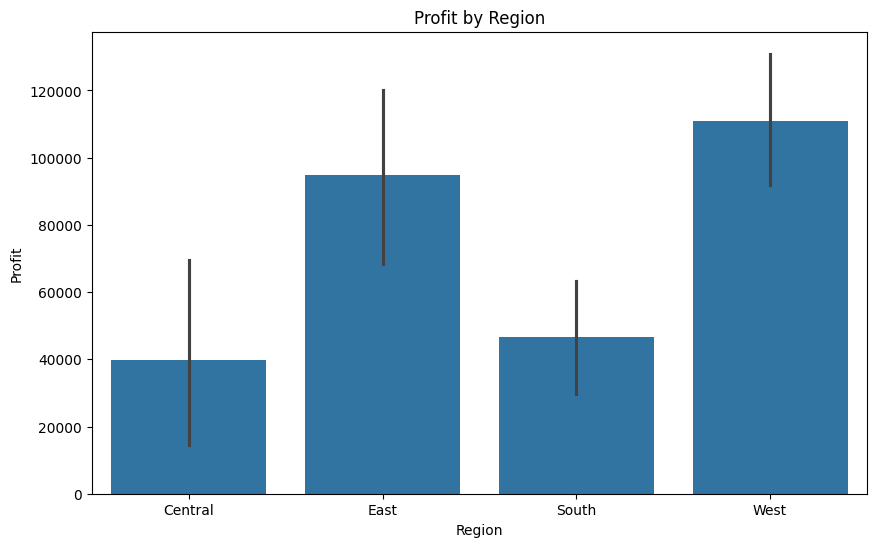

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Profit', estimator=sum)
plt.title('Profit by Region')
plt.show()


## 9. Zaman Bazlı Görselleştirme

In [31]:
# Bu bölümde yıllara ve aylara göre satış değişimini görselleştireceğim.

In [32]:
yearly_sales = df.groupby('Order Year')['Sales'].sum().reset_index()
fig = px.line(yearly_sales, x='Order Year', y='Sales', markers=True, title='Yearly Sales Trend')
fig.show()


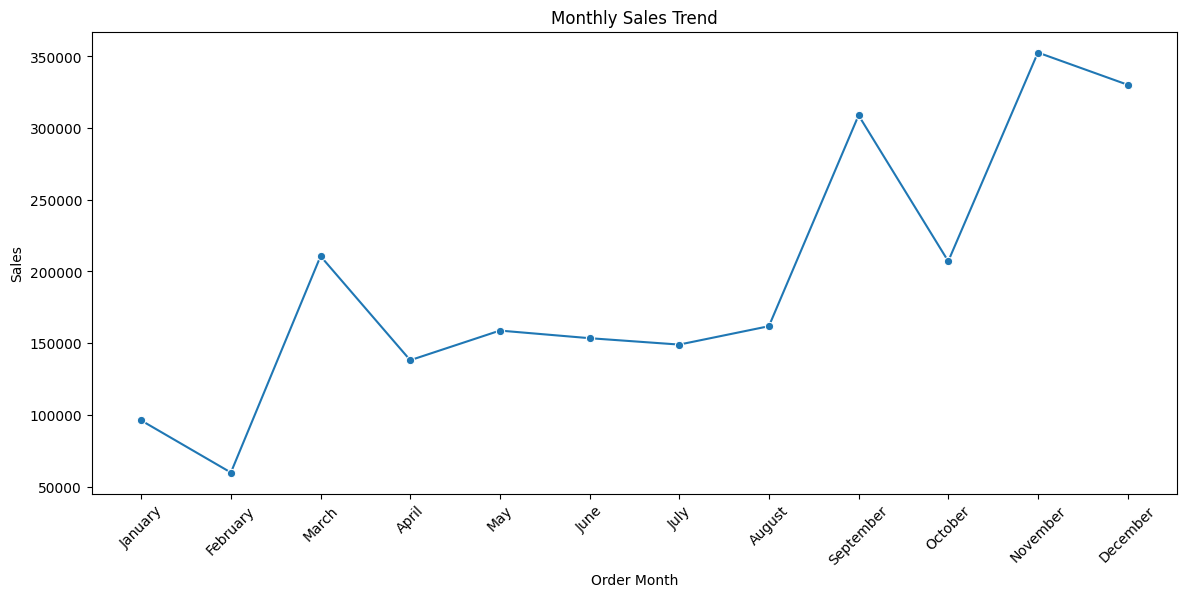

In [33]:
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['Order Month'] = pd.Categorical(monthly_sales['Order Month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('Order Month')

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x='Order Month', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()


## 10. Sonuç

Bu projede satış verileri görselleştirme odaklı olarak analiz edildi. Elde edilen grafikler ve dashboard çıktıları ile satış, kâr, bölge, kategori ve zaman ilişkileri anlaşılır şekilde ortaya kondu.